### **ANALYSING MACHINE LEARNING AND ANOMALY DETECTION TECHNIQUES FOR CREDIT CARD FRAUD DETECTION**

### **DATA VISUALISATION**

Load the credit card transaction dataset into a Pandas DataFrame, Display the first few rows to understand the dataset structure

In [3]:
import pandas as pd
#Dataset Reading
df = pd.read_csv("/content/drive/MyDrive/DISSETATION/archive/creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Check for NULL Values

In [4]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### Analyse the distribution of legitimate and fraudulent transaction

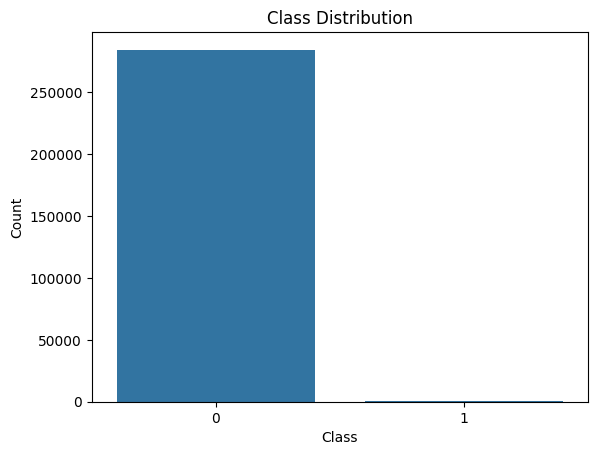

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [5]:
#Class Distribution and Percentage
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

print(df['Class'].value_counts(normalize=True) * 100)

### Plot for the distribution of transaction amounts

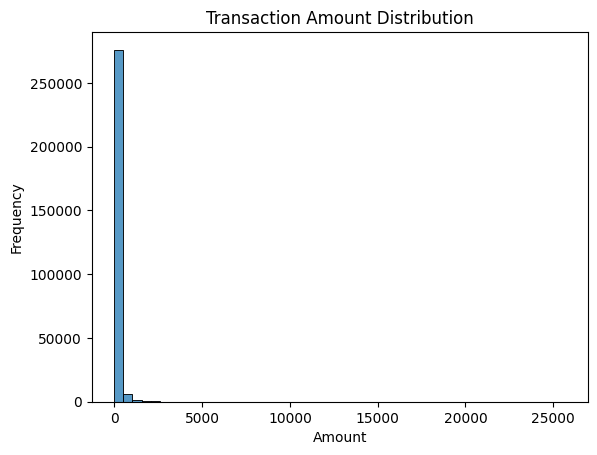

In [6]:
plt.figure()
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

### Correlation heatmap for all features

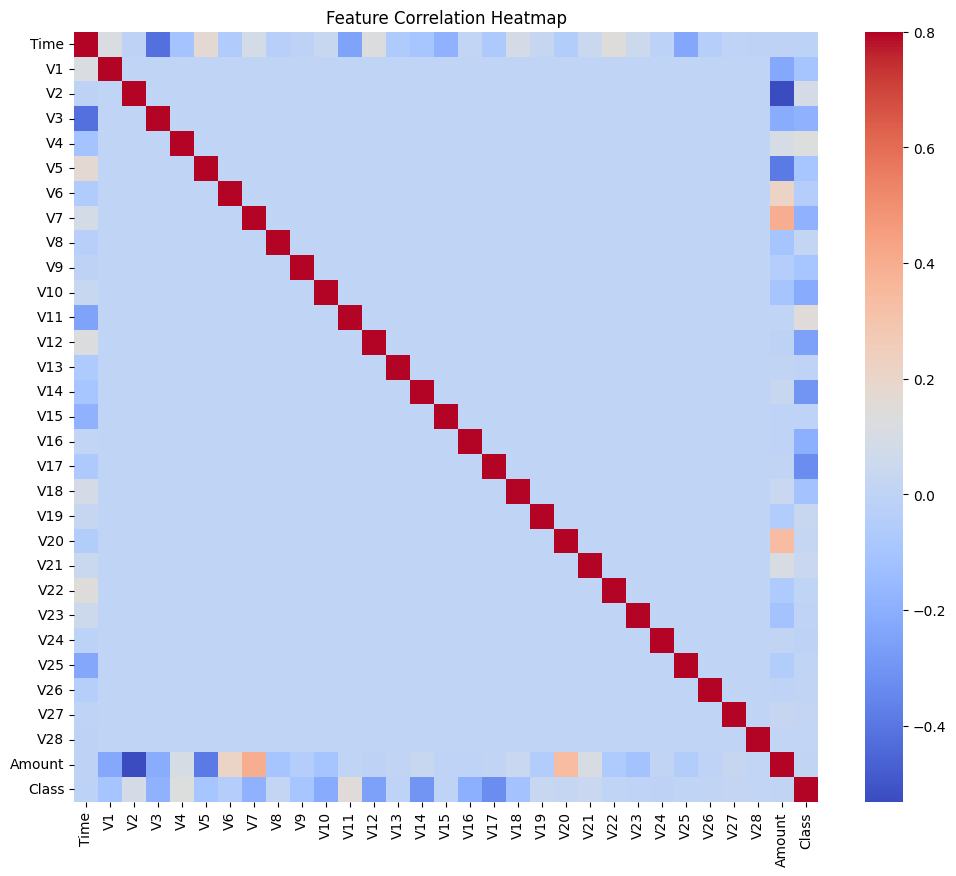

In [7]:
#Feature Correlation Heatmap
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', vmax=0.8)
plt.title('Feature Correlation Heatmap')
plt.show()

### Plot for the distribution of transaction time

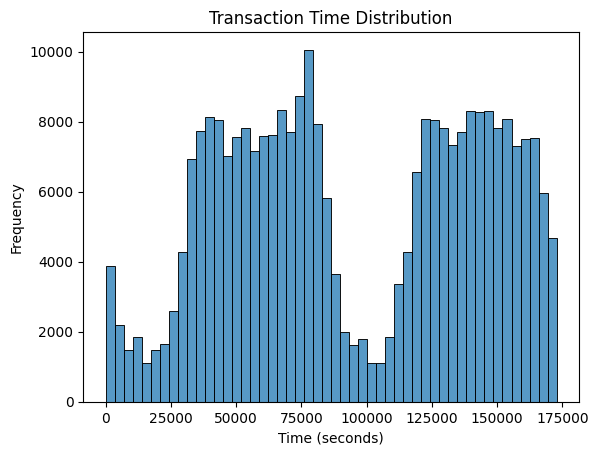

In [8]:
plt.figure()
sns.histplot(df['Time'], bins=50)
plt.title('Transaction Time Distribution')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.show()

### Compare transaction amount distribution between fraud and non-fraud classes

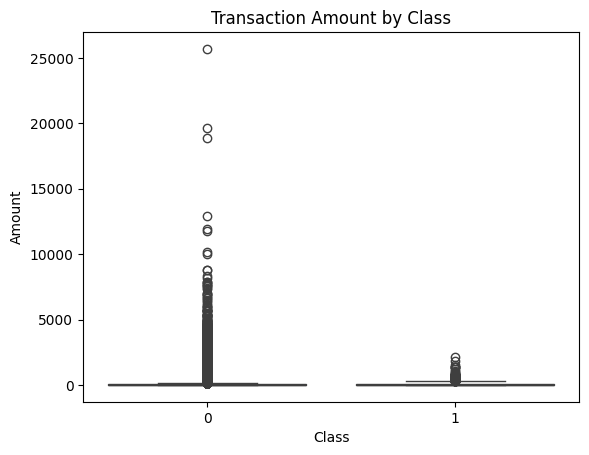

In [9]:
plt.figure()
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.xlabel('Class')
plt.ylabel('Amount')
plt.show()

### **DATA PREPARATION**

### Import libraries for data handling, preprocessing, visualisation,machine learning models, deep learning models, and evaluation metrics

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest, VotingClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
import lightgbm as lgb

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (classification_report, roc_auc_score,average_precision_score,confusion_matrix,roc_curve,precision_recall_curve)

In [11]:
df = pd.read_csv("/content/drive/MyDrive/DISSETATION/archive/creditcard.csv")

### **DATA PREPARATION**

Standardise the Time and Amount features using StandardScaler

Scale only 'Amount' and 'Time'

In [12]:
scaler_basic = StandardScaler()
df[['Time', 'Amount']] = scaler_basic.fit_transform(df[['Time', 'Amount']])

Separate features and target variable

In [13]:
X = df.drop('Class', axis=1)
y = df['Class']

Split the dataset into training and testing sets using stratified sampling

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Handling Class Imbalance


Apply SMOTE to the training dataset only(This prevents data leakage and balances fraud and non-fraud classes)

In [15]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

### **MODELLING**

## Logistic Regression

Train Logistic Regression as a baseline classification model, Generate predictions and prediction probabilities, Evaluate the model using classification metrics

In [16]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

print("\nLogistic Regression")
print(classification_report(y_test, lr.predict(X_test)))
y_pred_lr = lr.predict(X_test)
y_score_lr = lr.predict_proba(X_test)[:,1]


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



## Random Forest

Train Random Forest classifier to capture complex non-linear relationships, Generate predictions and probability scores, Evaluate model performance using precision, recall, F1-score, and ROC-AUC

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

print("\nRandom Forest")
print(classification_report(y_test, rf.predict(X_test)))
y_pred_rf = rf.predict(X_test)
y_score_rf = rf.predict_proba(X_test)[:,1]


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### XG Boost

Train XGBoost classifier using gradient boosting, Generate predictions and predicted probabilities, Evaluate the performance of the model

In [18]:
xgb = XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8,random_state=42)

xgb.fit(X_train_res, y_train_res)

print("\nXGBoost")
print(classification_report(y_test, xgb.predict(X_test)))
y_pred_xgb = xgb.predict(X_test)
y_score_xgb = xgb.predict_proba(X_test)[:,1]


XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.89      0.74        98

    accuracy                           1.00     56962
   macro avg       0.82      0.94      0.87     56962
weighted avg       1.00      1.00      1.00     56962



### LightGBM

Train LightGBM classifier for efficient gradient boosting, Generate predictions and probability scores, Evaluate the classification performance

In [19]:
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
lgb_model.fit(X_train_res, y_train_res)

print("\nLightGBM")
print(classification_report(y_test, lgb_model.predict(X_test)))
y_pred_lgb = lgb_model.predict(X_test)
y_score_lgb = lgb_model.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.261697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

LightGBM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.49      0.87      0.62        98

    accuracy                           1.00     56962
   macro avg       0.74      0.93      0.81     56962
weighted avg       1.00      1.00      1.00     56962



### MLP

Train a neural network model with hidden layers, Generate predictions and probability scores, Evaluate neural network performance

In [20]:
scaler_nn = StandardScaler()

X_train_res_scaled = scaler_nn.fit_transform(X_train_res)
X_test_scaled = scaler_nn.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42)
mlp.fit(X_train_res_scaled, y_train_res)

print("\nMLP")
print(classification_report(y_test, mlp.predict(X_test_scaled)))
y_pred_mlp = mlp.predict(X_test_scaled)
y_score_mlp = mlp.predict_proba(X_test_scaled)[:,1]


MLP
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.84      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



### Auto Encoder

Build and train the Autoencoder using only normal transactions,Calculate reconstruction error for anomaly detection, Classify transactions based on reconstruction error threshold, Evaluate anomaly detection performance

In [21]:
scaler_ae = StandardScaler()

X_train_scaled_ae = scaler_ae.fit_transform(X_train)
X_test_scaled_ae = scaler_ae.transform(X_test)

X_train_norm = X_train_scaled_ae[y_train == 0]

input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded)

decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_train_norm, X_train_norm,
                epochs=50,
                batch_size=256,
                validation_split=0.2,
                verbose=0)

# Reconstruction error
train_pred = autoencoder.predict(X_train_scaled_ae)
train_mse = np.mean((X_train_scaled_ae - train_pred)**2, axis=1)

test_pred = autoencoder.predict(X_test_scaled_ae)
test_mse = np.mean((X_test_scaled_ae - test_pred)**2, axis=1)

threshold = np.percentile(train_mse, 99.5)

y_pred_ae = (test_mse > threshold).astype(int)
y_score_ae = test_mse

print("\nAutoencoder")
print(classification_report(y_test, y_pred_ae))


7121/7121 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Autoencoder
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.27      0.79      0.40        98

    accuracy                           1.00     56962
   macro avg       0.63      0.89      0.70     56962
weighted avg       1.00      1.00      1.00     56962



### Auto Encoder + LightGBM

Use Autoencoder reconstruction error as an additional feature, Train LightGBM using the enhanced feature set, Generate predictions and evaluate hybrid model performance

In [22]:
X_train_res_scaled_ae = scaler_ae.transform(X_train_res)
train_res_pred = autoencoder.predict(X_train_res_scaled_ae)
train_res_mse = np.mean((X_train_res_scaled_ae - train_res_pred)**2, axis=1)

X_train_res_df = pd.DataFrame(X_train_res)
X_test_df = pd.DataFrame(X_test)

X_train_res_df['ae_error'] = train_res_mse
X_test_df['ae_error'] = test_mse

lgb_hybrid = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
lgb_hybrid.fit(X_train_res_df, y_train_res)

y_pred_hybrid = lgb_hybrid.predict(X_test_df)
y_score_hybrid = lgb_hybrid.predict_proba(X_test_df)[:,1]

print("\nHybrid Model")
print(classification_report(y_test, lgb_hybrid.predict(X_test_df)))



14216/14216 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step
[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.266930 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7905
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Hybrid Model
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.49      0.90      0.64        98

    accuracy                           1.00     56962
   macro avg       0.75      0.95      0.82     56962
weighted avg       1.00      1.00      1.00     56962



### Voting Ensemble

Combine Random Forest and XGBoost using soft voting ensemble, Generate ensemble predictions and probability scores, Evaluate ensemble model performance

In [23]:
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)

ensemble.fit(X_train_res, y_train_res)

y_pred_ens = ensemble.predict(X_test)
y_score_ens = ensemble.predict_proba(X_test)[:,1]

print("\nVoting Ensemble")
print(classification_report(y_test, ensemble.predict(X_test)))


Voting Ensemble
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.86      0.82        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



Create a comparison table for all models
Compare Precision, Recall, F1-score, and ROC-AUC values
Plot confusion matrices for all implemented models
Analyse true positives, false positives, true negatives, and false negatives
Plot Precision–Recall curves for all models
Analyse fraud detection effectiveness on imbalanced data
Create bar chart comparing F1-scores of all models
Identify models with the best balance between precision and recall
Summarise findings from all implemented models
Identify the best-performing model for fraud detection

### Create a comparison table for all models

In [25]:
#CREATE RESULTS TABLE

def get_metrics(name, y_true, y_pred, y_score):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "Model": name,
        "Precision": rep["1"]["precision"],
        "Recall": rep["1"]["recall"],
        "F1": rep["1"]["f1-score"],
        "Accuracy": rep["accuracy"],
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score)
    }

results = []

results.append(get_metrics("Logistic Regression", y_test, y_pred_lr, y_score_lr))
results.append(get_metrics("Random Forest", y_test, y_pred_rf, y_score_rf))
results.append(get_metrics("XGBoost", y_test, y_pred_xgb, y_score_xgb))
results.append(get_metrics("LightGBM", y_test, y_pred_lgb, y_score_lgb))
results.append(get_metrics("MLP", y_test, y_pred_mlp, y_score_mlp))
results.append(get_metrics("Autoencoder", y_test, y_pred_ae, y_score_ae))
results.append(get_metrics("Hybrid", y_test, y_pred_hybrid, y_score_hybrid))
results.append(get_metrics("Voting Ensemble", y_test, y_pred_ens, y_score_ens))

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="F1", ascending=False)

print("\nFINAL RESULTS TABLE:")
print(df_results.round(4))


FINAL RESULTS TABLE:
                 Model  Precision  Recall      F1  Accuracy  ROC-AUC  PR-AUC
1        Random Forest     0.8454  0.8367  0.8410    0.9995   0.9731  0.8747
7      Voting Ensemble     0.7850  0.8571  0.8195    0.9994   0.9786  0.8743
4                  MLP     0.7593  0.8367  0.7961    0.9993   0.9540  0.8261
2              XGBoost     0.6350  0.8878  0.7404    0.9989   0.9769  0.8687
6               Hybrid     0.4916  0.8980  0.6354    0.9982   0.9834  0.8555
3             LightGBM     0.4857  0.8673  0.6227    0.9982   0.9503  0.8210
5          Autoencoder     0.2664  0.7857  0.3979    0.9959   0.9429  0.5851
0  Logistic Regression     0.0581  0.9184  0.1094    0.9743   0.9698  0.7249


### Compare Precision, Recall, F1-score, and ROC-AUC values

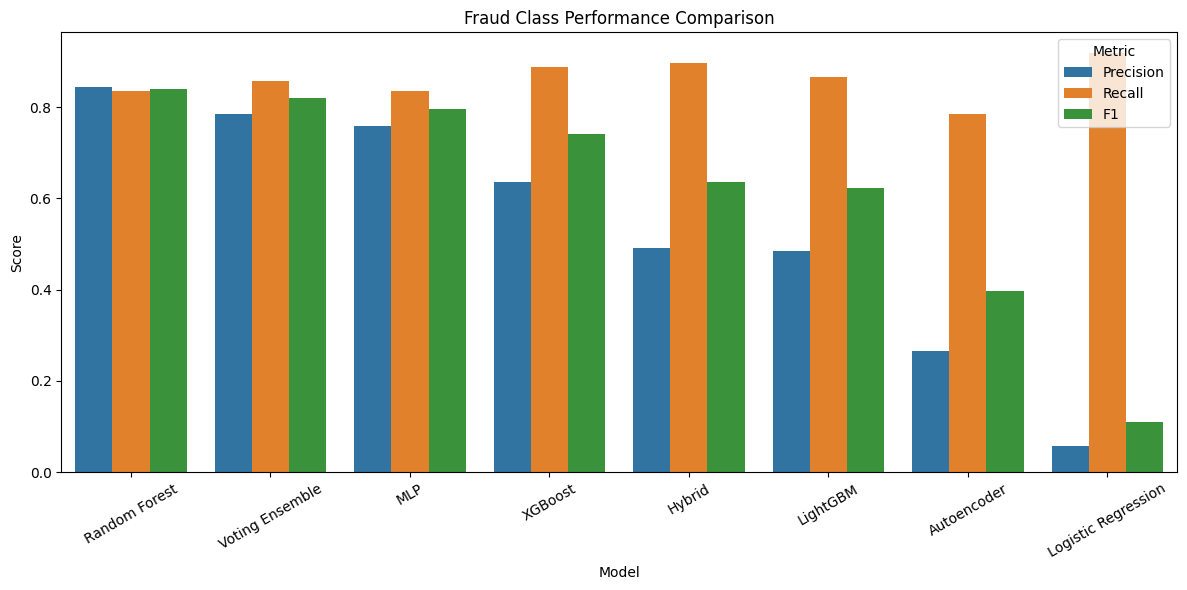

In [26]:
#BAR PLOT FOR ALL MODELS

df_melt = df_results.melt(id_vars="Model",value_vars=["Precision", "Recall", "F1"],var_name="Metric",value_name="Score")
plt.figure(figsize=(12,6))
sns.barplot(data=df_melt, x="Model", y="Score", hue="Metric")
plt.xticks(rotation=30)
plt.title("Fraud Class Performance Comparison")
plt.tight_layout()
plt.show()

### Plot ROC-AUC plot for all models

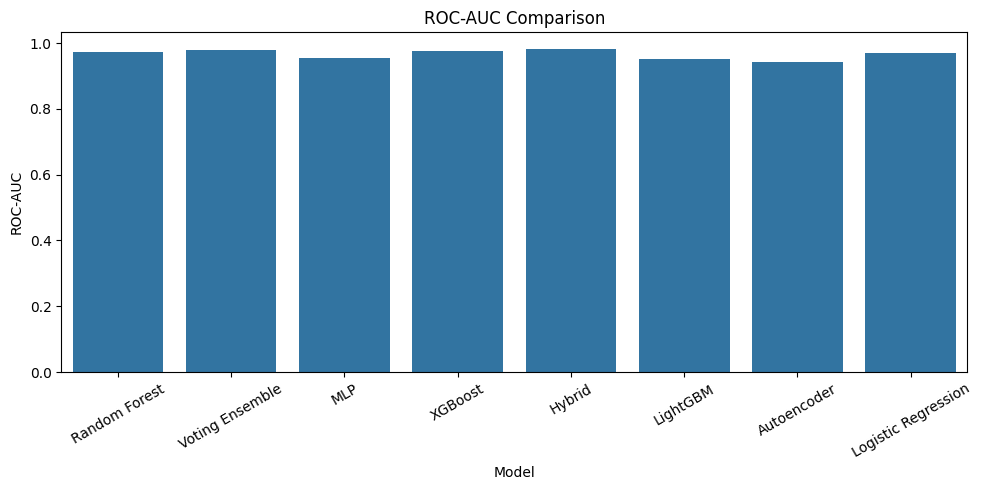

In [27]:
#ROC-AUC COMPARISON

plt.figure(figsize=(10,5))
sns.barplot(data=df_results, x="Model", y="ROC-AUC")
plt.xticks(rotation=30)
plt.title("ROC-AUC Comparison")
plt.tight_layout()
plt.show()

### Plot Precision–Recall curves for all models

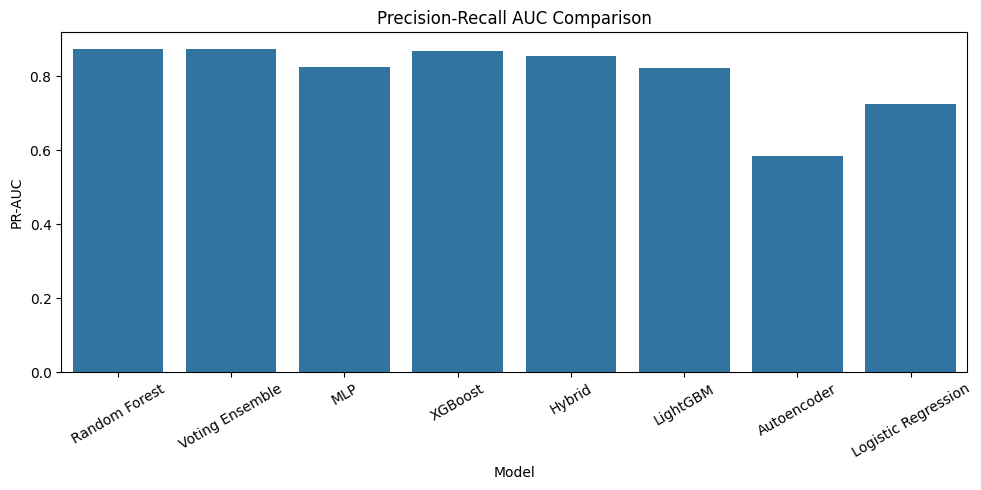

In [28]:
#PRECISION-RECALL AUC CURVE

plt.figure(figsize=(10,5))
sns.barplot(data=df_results, x="Model", y="PR-AUC")
plt.xticks(rotation=30)
plt.title("Precision-Recall AUC Comparison")
plt.tight_layout()
plt.show()

### CONFUSION MATRICES FOR ALL MODELS

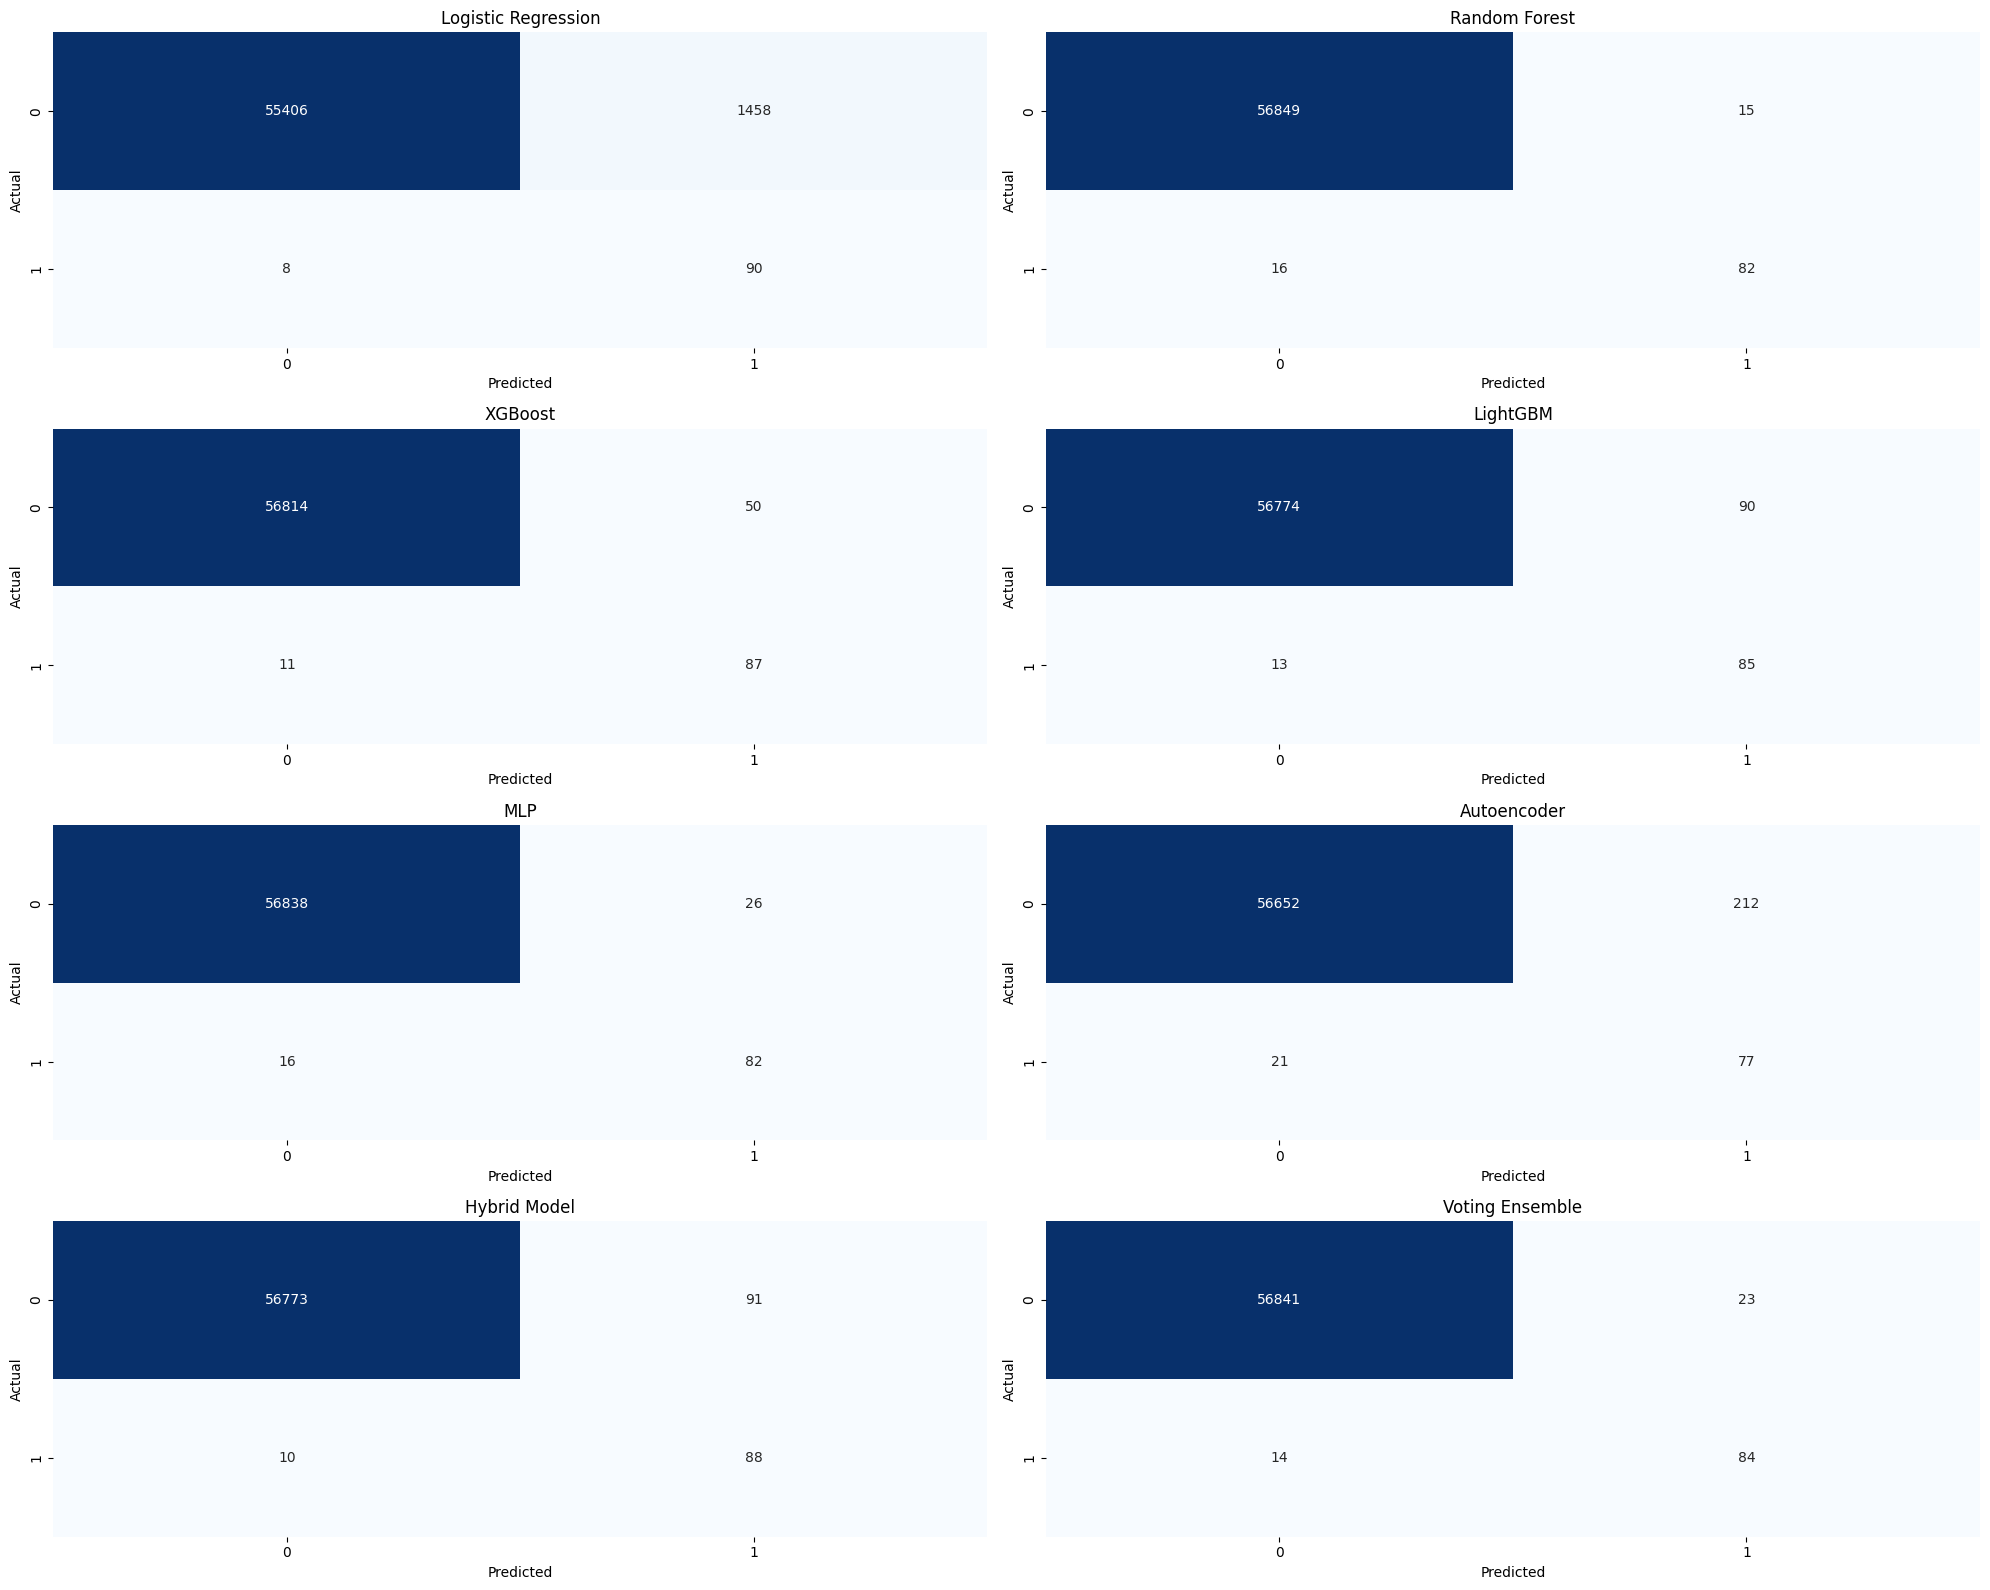

In [29]:
all_models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "MLP": y_pred_mlp,
    "Autoencoder": y_pred_ae,
    "Hybrid Model": y_pred_hybrid,
    "Voting Ensemble": y_pred_ens
}

plt.figure(figsize=(20, 16))

for i, (name, preds) in enumerate(all_models.items(), 1):
    plt.subplot(4, 2, i)

    cm = confusion_matrix(y_test, preds)

    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False)

    plt.title(name, fontsize=12)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()


### Plot ROC curves for all models

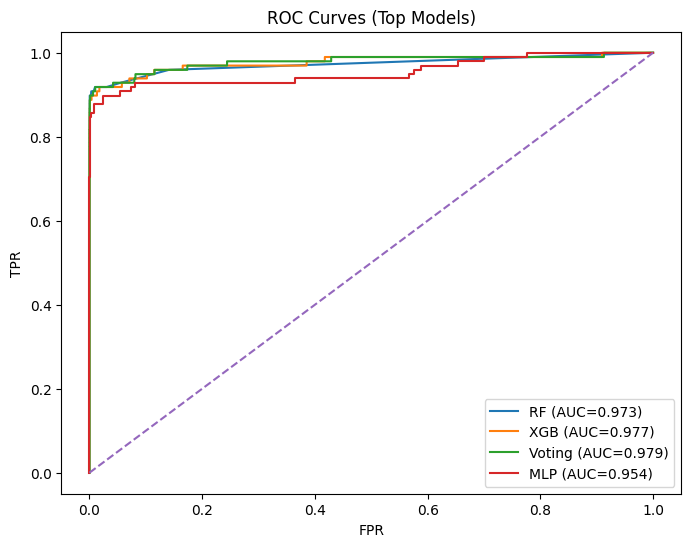

In [30]:
#ROC CURVES

score_map = {
    "RF": y_score_rf,
    "XGB": y_score_xgb,
    "Voting": y_score_ens,
    "MLP": y_score_mlp
}

plt.figure(figsize=(8,6))

for name, score in score_map.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curves (Top Models)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

### Final Analysis to determine the best models

In [31]:
#FINAL ANALYSIS

best_f1 = df_results.iloc[0]
best_recall = df_results.sort_values("Recall", ascending=False).iloc[0]
best_precision = df_results.sort_values("Precision", ascending=False).iloc[0]

print("\nFINAL INSIGHTS:")
print(f"Best Overall Model (F1): {best_f1['Model']}")
print(f"Best Fraud Detection (Recall): {best_recall['Model']}")
print(f"Best Precision (Least False Alarms): {best_precision['Model']}")


FINAL INSIGHTS:
Best Overall Model (F1): Random Forest
Best Fraud Detection (Recall): Logistic Regression
Best Precision (Least False Alarms): Random Forest
